In [1]:
import os, json, glob, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

# Device selection (Optimized for Apple Silicon or NVIDIA)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training Hardware Confirmed: {device}")

🚀 Training Hardware Confirmed: mps


In [2]:
#New-preprocessing
import os, glob, json, rasterio
import numpy as np
from rasterio.windows import Window
from rasterio import features
from shapely.geometry import Polygon

# --- CONFIGURATION ---
TILE_SIZE = 512
OVERLAP = 128
RAW_DIR = "../raw_data"
OUT_DIR = "../train_data"
# Using a list of prefixes for cleaner matching
REQUIRED_STORMS = [
    '1001-Ian-01', '1001-Ian-02', '1001-Ian-03', '1001-Ian-04', '1001-Ian-05', 
    '1001-Ian-06', '1001-Ian-07', '1001-Ian-08', '1001-Ian-09', '1001-Ian-10', 
    '1001-Ian-11', '1002-Ian-01', '1002-Ian-02', '1002-Ian-03', 
    'laura-01', 'laura-02', 'Idalia-01', 'Idalia-02', 'Michael-01', 'Michael-02'
]

def preprocess_specific_storms():
    os.makedirs(os.path.join(OUT_DIR, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUT_DIR, "masks"), exist_ok=True)
    
    stride = TILE_SIZE - OVERLAP 
    all_tif_files = glob.glob(os.path.join(RAW_DIR, "*.tif"))
    
    # Filter for specific hurricane events
    filtered_files = [
        f for f in all_tif_files 
        if any(storm_id in os.path.basename(f) for storm_id in REQUIRED_STORMS)
    ]
    
    print(f"🔍 Found {len(filtered_files)} large TIFFs to process.")

    for tif_path in filtered_files:
        # Clean naming logic to handle various underscore/dash conventions
        file_prefix = os.path.basename(tif_path).replace('.tif', '').replace('_tif', '')
        
        base_json = os.path.join(RAW_DIR, f"{file_prefix}_json.json")
        align_json = os.path.join(RAW_DIR, f"{file_prefix}_json_aligned.json")
        
        if not (os.path.exists(base_json) and os.path.exists(align_json)):
            print(f"⚠️ Skipping {file_prefix}: Missing JSON labels.")
            continue

        print(f"🏗️ Processing: {file_prefix}...")

        try:
            with rasterio.open(tif_path) as src:
                # Calculate alignment shift
                with open(align_json) as f:
                    align_data = json.load(f)
                s_x = np.mean([p[1][0] - p[0][0] for p in align_data])
                s_y = np.mean([p[1][1] - p[0][1] for p in align_data])
                
                # Extract Polygons
                with open(base_json) as f:
                    polys = []
                    for entry in json.load(f):
                        if 'pixels' in entry:
                            coords = [(p['x'] + s_x, p['y'] + s_y) for p in entry['pixels']]
                            world_coords = [src.transform * (px, py) for px, py in coords]
                            polys.append(Polygon(world_coords))

                tile_count = 0
                # Optimized looping: ensures we don't go out of bounds
                for y in range(0, src.height - TILE_SIZE, stride):
                    for x in range(0, src.width - TILE_SIZE, stride):
                        window = Window(x, y, TILE_SIZE, TILE_SIZE)
                        
                        # Rasterize mask
                        mask = features.rasterize(
                            polys, 
                            out_shape=(TILE_SIZE, TILE_SIZE), 
                            transform=src.window_transform(window), 
                            fill=0, default_value=1, dtype=np.uint8
                        )
                        
                        # Filter for tiles with building footprints
                        if np.sum(mask) > 10: 
                            img_patch = src.read([1, 2, 3], window=window)
                            
                            # SAFETY: Check for black/nodata tiles
                            if np.mean(img_patch) < 1: continue 

                            tile_id = f"{file_prefix}_y{y}_x{x}.npy"
                            # Transpose to (H, W, C) for easier plotting later
                            np.save(os.path.join(OUT_DIR, "images", tile_id), img_patch.transpose(1, 2, 0))
                            np.save(os.path.join(OUT_DIR, "masks", tile_id), mask)
                            tile_count += 1
                
                print(f"   ✅ Created {tile_count} tiles.")

        except Exception as e:
            print(f"❌ CRITICAL ERROR on {file_prefix}: {e}")
            continue
        
    print("\n🚀 Preprocessing Complete! Ready for EfficientNet-B4 Training.")

# Execute
preprocess_specific_storms()

🔍 Found 20 large TIFFs to process.
🏗️ Processing: 1001-Ian-03...
   ✅ Created 1826 tiles.
🏗️ Processing: 1001-Ian-02...
   ✅ Created 5446 tiles.
🏗️ Processing: laura-01...
   ✅ Created 1985 tiles.
🏗️ Processing: 1002-Ian-01...
   ✅ Created 6812 tiles.
🏗️ Processing: 1001-Ian-10...
   ✅ Created 1673 tiles.
🏗️ Processing: 1002-Ian-03...
   ✅ Created 944 tiles.
🏗️ Processing: 1001-Ian-09...
   ✅ Created 4325 tiles.
🏗️ Processing: 1002-Ian-02...
   ✅ Created 670 tiles.
🏗️ Processing: 1001-Ian-08...
   ✅ Created 878 tiles.
🏗️ Processing: laura-02...
   ✅ Created 114 tiles.
🏗️ Processing: 1001-Ian-01...
   ✅ Created 6362 tiles.
🏗️ Processing: 1001-Ian-11...
   ✅ Created 5182 tiles.
🏗️ Processing: 1001-Ian-04...
   ✅ Created 4303 tiles.
🏗️ Processing: Michael-02...
   ✅ Created 6787 tiles.
🏗️ Processing: 1001-Ian-05...
   ✅ Created 3721 tiles.
🏗️ Processing: Idalia-01...
   ✅ Created 747 tiles.
🏗️ Processing: 1001-Ian-07...
   ✅ Created 4145 tiles.
🏗️ Processing: 1001-Ian-06...
   ✅ Created 2

In [3]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, Subset
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- 1. PRECISE TRANSFORMATIONS ---
# Train: Heavy augmentation to learn geometry (Fixed A.Flip error)
train_transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),  # Replaces the deprecated A.Flip()
    A.VerticalFlip(p=0.5),    # Replaces the deprecated A.Flip()
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.OneOf([
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=1),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=1),
    ], p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# Test: Only normalization
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# --- 2. DATASET DEFINITION ---
class DisasterDataset(Dataset):
    def __init__(self, root_dir='../train_data', transform=None):
        self.img_dir = os.path.join(root_dir, 'images')
        self.mask_dir = os.path.join(root_dir, 'masks')
        # Ensure the directory exists before listing
        if not os.path.exists(self.img_dir):
            raise FileNotFoundError(f"Directory not found: {self.img_dir}")
            
        self.filenames = sorted([f for f in os.listdir(self.img_dir) if f.endswith('.npy')])
        self.transform = transform

    def __len__(self): 
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img = np.load(os.path.join(self.img_dir, fname)) # (H, W, C)
        mask = np.load(os.path.join(self.mask_dir, fname))
        
        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented['image'], augmented['mask']
        
        # Ensure mask has a channel dimension for PyTorch (1, H, W)
        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)
            
        return img, mask.float()

# --- 3. TARGETED SPLIT (Corrected Loader Logic) ---
# We initialize the base dataset to get filenames
base_dataset = DisasterDataset()

# Filter indices for the split
train_indices = [i for i, f in enumerate(base_dataset.filenames) if not any(x in f for x in ['Idalia', 'Michael'])]
test_indices = [i for i, f in enumerate(base_dataset.filenames) if any(x in f for x in ['Idalia', 'Michael'])]

# Create separate dataset instances to apply different transforms to the same raw data
train_loader = DataLoader(
    Subset(DisasterDataset(transform=train_transform), train_indices), 
    batch_size=12, 
    shuffle=True
)

test_loader = DataLoader(
    Subset(DisasterDataset(transform=val_transform), test_indices), 
    batch_size=1, 
    shuffle=False
)

print(f"📊 Dataset Ready: {len(train_indices)} training tiles, {len(test_indices)} generalization test tiles.")

📊 Dataset Ready: 53524 training tiles, 14106 generalization test tiles.


/Users/shashank/miniconda3/envs/wlstm/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [4]:
# --- 4. ARCHITECTURE ---
model = smp.Unet(
    encoder_name="efficientnet-b4", 
    encoder_weights="imagenet", 
    in_channels=3, 
    classes=1, 
    activation=None, # Output raw logits for better numerical stability
    decoder_attention_type='scse' 
).to(device)

# --- 5. CORRECTED LOSS & OPTIMIZER ---
# By setting gamma=2.0, this standard TverskyLoss behaves as Focal Tversky Loss.
criterion = smp.losses.TverskyLoss(
    mode='binary', 
    alpha=0.3,      # Penalize False Positives
    beta=0.7,       # Penalize False Negatives (Prioritize finding buildings)
    gamma=2.0,      # The "Focal" parameter for hard-pixel mining
    from_logits=True
)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)

In [5]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [6]:
from tqdm import tqdm
import time

best_iou = 0.0
print(f"🔥 Training Started on {device}. Target: Idalia & Michael.")

for epoch in range(30):
    # --- TRAINING PHASE ---
    model.train()
    epoch_loss = 0
    
    # Wrap train_loader with tqdm for a percentage progress bar
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d} [Train]", unit="batch")
    
    for imgs, masks in train_pbar:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        
        output = model(imgs)
        loss = criterion(output, masks)
        loss.backward()
        optimizer.step()
        
        current_loss = loss.item()
        epoch_loss += current_loss
        
        # This updates the info at the end of the progress bar
        train_pbar.set_postfix({"loss": f"{current_loss:.4f}"})
    
    # --- VALIDATION PHASE ---
    model.eval()
    tp, fp, fn = 0, 0, 0
    
    # Wrap test_loader with tqdm
    val_pbar = tqdm(test_loader, desc=f"Epoch {epoch+1:02d} [Val]", unit="tile")
    
    with torch.no_grad():
        for imgs, masks in val_pbar:
            imgs, masks = imgs.to(device), masks.to(device)
            
            # Apply sigmoid to logits
            preds = (torch.sigmoid(model(imgs)) > 0.5).float()
            
            tp += (preds * masks).sum().item()
            fp += (preds * (1 - masks)).sum().item()
            fn += ((1 - preds) * masks).sum().item()
            
    iou = tp / (tp + fp + fn + 1e-7)
    scheduler.step()
    
    # Save best model logic
    status = "⭐ NEW BEST" if iou > best_iou else ""
    if iou > best_iou:
        best_iou = iou
        torch.save(model.state_dict(), "best_building_model.pth")
    
    # Final summary for the epoch
    print(f"✅ Epoch {epoch+1:02d} Finished | Train Loss: {epoch_loss/len(train_loader):.4f} | Test IoU: {iou:.4f} {status}\n")

🔥 Training Started on mps. Target: Idalia & Michael.


Epoch 01 [Val]: 100%|███████████████████████████████████████████████████████████| 14106/14106 [12:45<00:00, 18.43tile/s]


✅ Epoch 01 Finished | Train Loss: 0.0385 | Test IoU: 0.5293 ⭐ NEW BEST



Epoch 02 [Val]: 100%|███████████████████████████████████████████████████████████| 14106/14106 [16:23<00:00, 14.34tile/s]


✅ Epoch 02 Finished | Train Loss: 0.0252 | Test IoU: 0.5222 



...

✅ Epoch 28 Finished | Train Loss: 0.0138 | Test IoU: 0.5459 



Epoch 29 [Val]: 100%|███████████████████████████████████████████████████████████| 14106/14106 [06:53<00:00, 34.10tile/s]


✅ Epoch 29 Finished | Train Loss: 0.0135 | Test IoU: 0.5490 



Epoch 30 [Val]: 100%|███████████████████████████████████████████████████████████| 14106/14106 [07:12<00:00, 32.59tile/s]

✅ Epoch 30 Finished | Train Loss: 0.0134 | Test IoU: 0.5461 



🔬 Evaluating Generalization Metrics on Idalia & Michael...

🌍 GLOBAL PERFORMANCE REPORT
IoU             : 0.5461
Dice (F1-score) : 0.7064
Precision       : 0.6802
Recall (Target) : 0.7347
Specificity     : 0.8413
Balanced Acc.   : 0.7880
Overall Acc.    : 0.8077


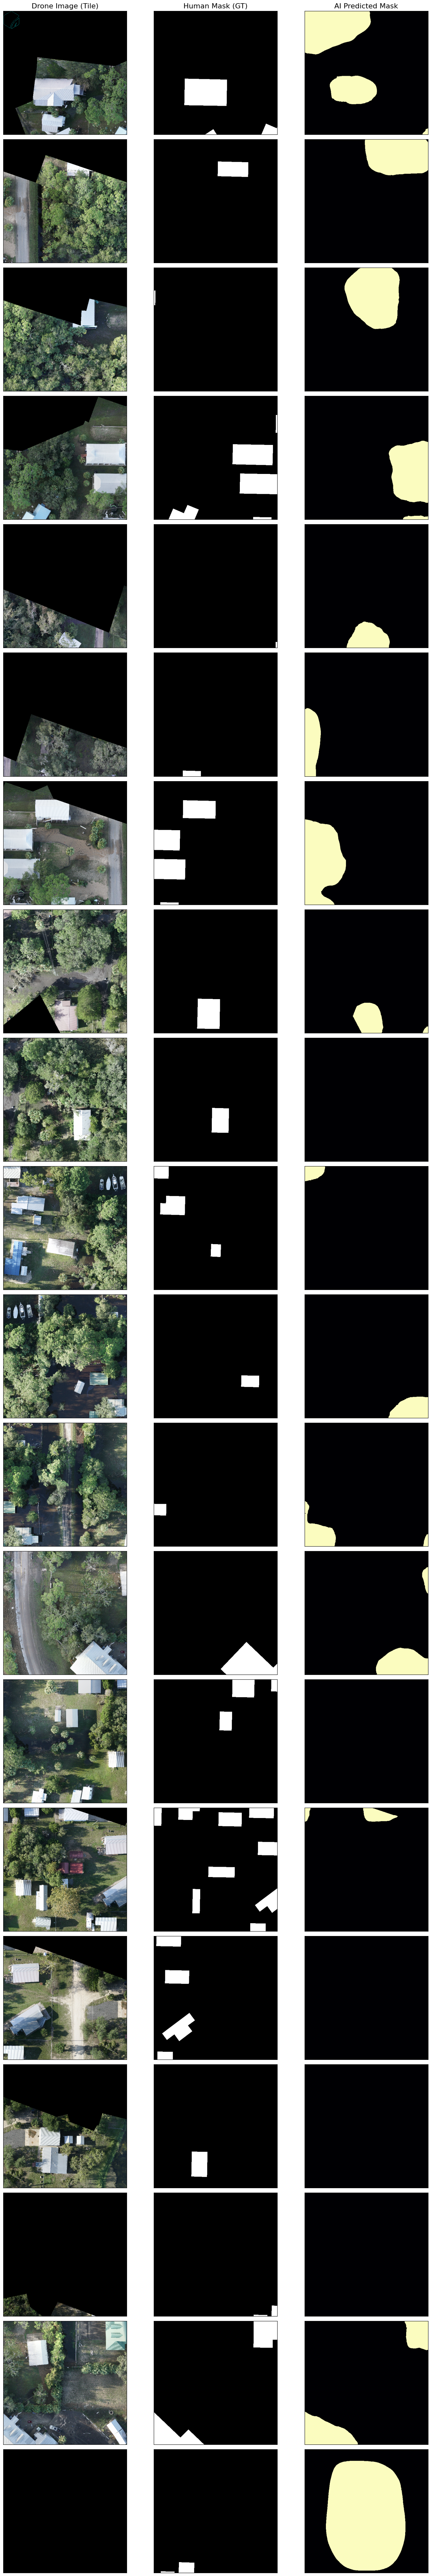

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def evaluate_and_visualize(loader, model, num_samples=20):
    model.eval()
    all_tp, all_fp, all_tn, all_fn = 0, 0, 0, 0
    samples = []
    
    print(f"🔬 Evaluating Generalization Metrics on Idalia & Michael...")
    
    with torch.no_grad():
        for i, (imgs, masks) in enumerate(loader):
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds = (outputs > 0.5).float()
            
            # Flatten for metric calculation
            p = preds.view(-1).cpu().numpy()
            m = masks.view(-1).cpu().numpy()
            
            # Update Pixel Counters
            tp = np.sum(p * m)
            fp = np.sum(p * (1 - m))
            tn = np.sum((1 - p) * (1 - m))
            fn = np.sum((1 - p) * m)
            
            all_tp += tp; all_fp += fp; all_tn += tn; all_fn += fn
            
            # Store 20 samples for the final grid
            if len(samples) < num_samples:
                samples.append({
                    'img': imgs[0].permute(1, 2, 0).cpu().numpy(),
                    'gt': masks[0][0].cpu().numpy(),
                    'pred': preds[0][0].cpu().numpy()
                })

    # --- 1. Metric Calculations ---
    eps = 1e-7
    iou = all_tp / (all_tp + all_fp + all_fn + eps)
    dice = (2 * all_tp) / (2 * all_tp + all_fp + all_fn + eps) # Dice is same as F1
    precision = all_tp / (all_tp + all_fp + eps)
    recall = all_tp / (all_tp + all_fn + eps)
    specificity = all_tn / (all_tn + all_fp + eps)
    accuracy = (all_tp + all_tn) / (all_tp + all_tn + all_fp + all_fn + eps)
    balanced_acc = (recall + specificity) / 2

    # --- 2. Display Metrics ---
    print("\n" + "="*30)
    print(f"🌍 GLOBAL PERFORMANCE REPORT")
    print("="*30)
    print(f"IoU             : {iou:.4f}")
    print(f"Dice (F1-score) : {dice:.4f}")
    print(f"Precision       : {precision:.4f}")
    print(f"Recall (Target) : {recall:.4f}")
    print(f"Specificity     : {specificity:.4f}")
    print(f"Balanced Acc.   : {balanced_acc:.4f}")
    print(f"Overall Acc.    : {accuracy:.4f}")
    print("="*30)

    # --- 3. 20-Tile Visualization Grid ---
    # We create a grid of 20 rows, 3 columns (Image, Human Mask, AI Pred)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 4 * num_samples))
    
    for idx, sample in enumerate(samples):
        # Image (De-normalized for visualization)
        img_display = sample['img'] * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)
        
        axes[idx, 0].imshow(img_display)
        axes[idx, 1].imshow(sample['gt'], cmap='gray')
        axes[idx, 2].imshow(sample['pred'], cmap='magma')
        
        # Titles for the first row
        if idx == 0:
            axes[idx, 0].set_title("Drone Image (Tile)", fontsize=16)
            axes[idx, 1].set_title("Human Mask (GT)", fontsize=16)
            axes[idx, 2].set_title("AI Predicted Mask", fontsize=16)
        
        # Remove axis ticks for cleanliness
        for j in range(3):
            axes[idx, j].set_xticks([]); axes[idx, j].set_yticks([])

    plt.tight_layout()
    plt.savefig("final_performance_grid.png", dpi=300)
    plt.show()

# EXECUTE
evaluate_and_visualize(test_loader, model, num_samples=20)